## Normalização de Dados
Jéssica Kushida (23012069) <br></br>
Natália Naomi Sumida (23008255) 
<br></br>

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mean_absolute_error
from sklearn.experimental import enable_iterative_imputer



In [105]:
# 1. Importando base de dados wine
from sklearn.datasets import load_wine
data = load_wine()
dfWine = pd.DataFrame(data.data, columns=data.feature_names)

In [106]:
# 2. Analise descritiva
# A - Estatisticas gerais
dfWine.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [107]:
# B - Tipos de dados de cada coluna
dfWine.info()
print('\n**ou** \n\n', dfWine.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

### Normalizacao dos dados numericos

In [108]:
#StandardScaler
standardScaler = StandardScaler()
dfStandard = pd.DataFrame(standardScaler.fit_transform(dfWine), columns=dfWine.columns)

#MinMaxScaler
minMaxScaler = MinMaxScaler()
dfMinMax = pd.DataFrame(minMaxScaler.fit_transform(dfWine), columns=dfWine.columns)

### Histogramas

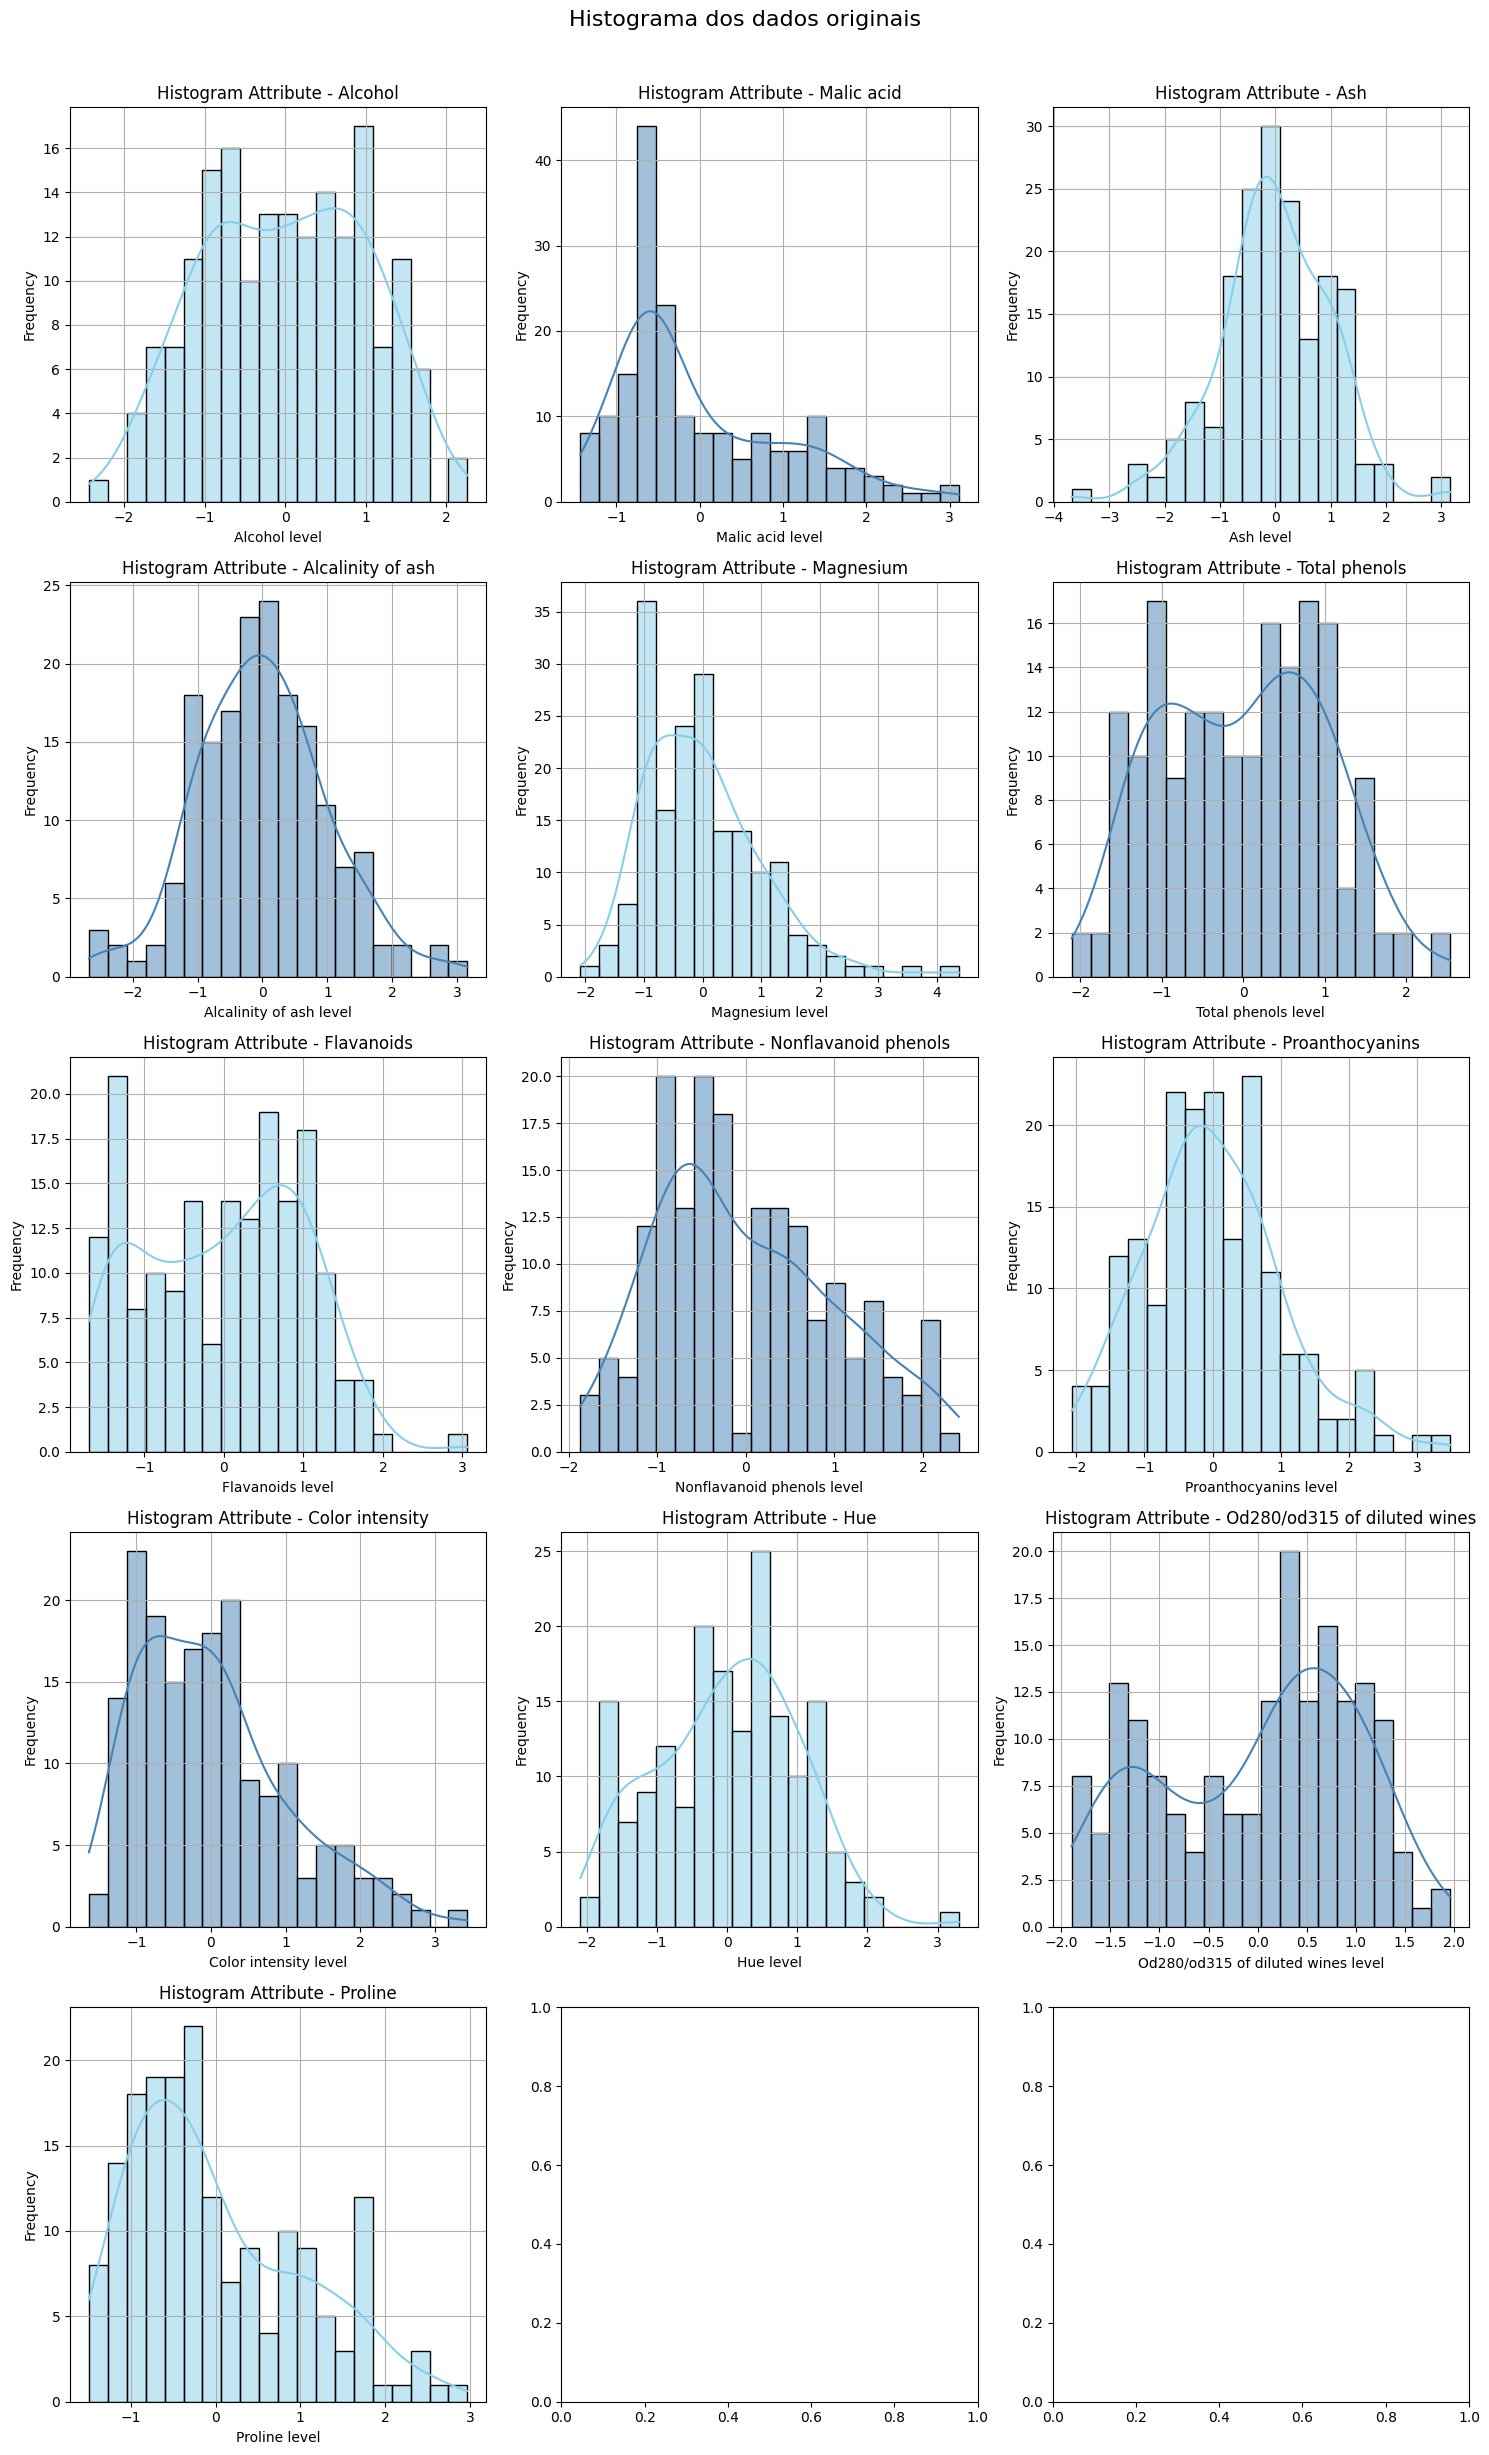

In [109]:
colors = ['skyblue', 'steelblue']
count = 0
fig, axes = plt.subplots(nrows=len(dfStandard.columns) // 3 + 1, ncols=3, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(dfWine.select_dtypes(include=['float64']).columns):
    sns.histplot(dfStandard[col], kde=True, bins=20, color=colors[count % 2], ax=axes[i])
    colName = col.capitalize().replace('_', ' ')
    axes[i].set_title(f"Histogram Attribute - {colName}")
    axes[i].set_xlabel(f"{colName} level")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    count += 1

plt.suptitle("Histograma dos dados originais", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


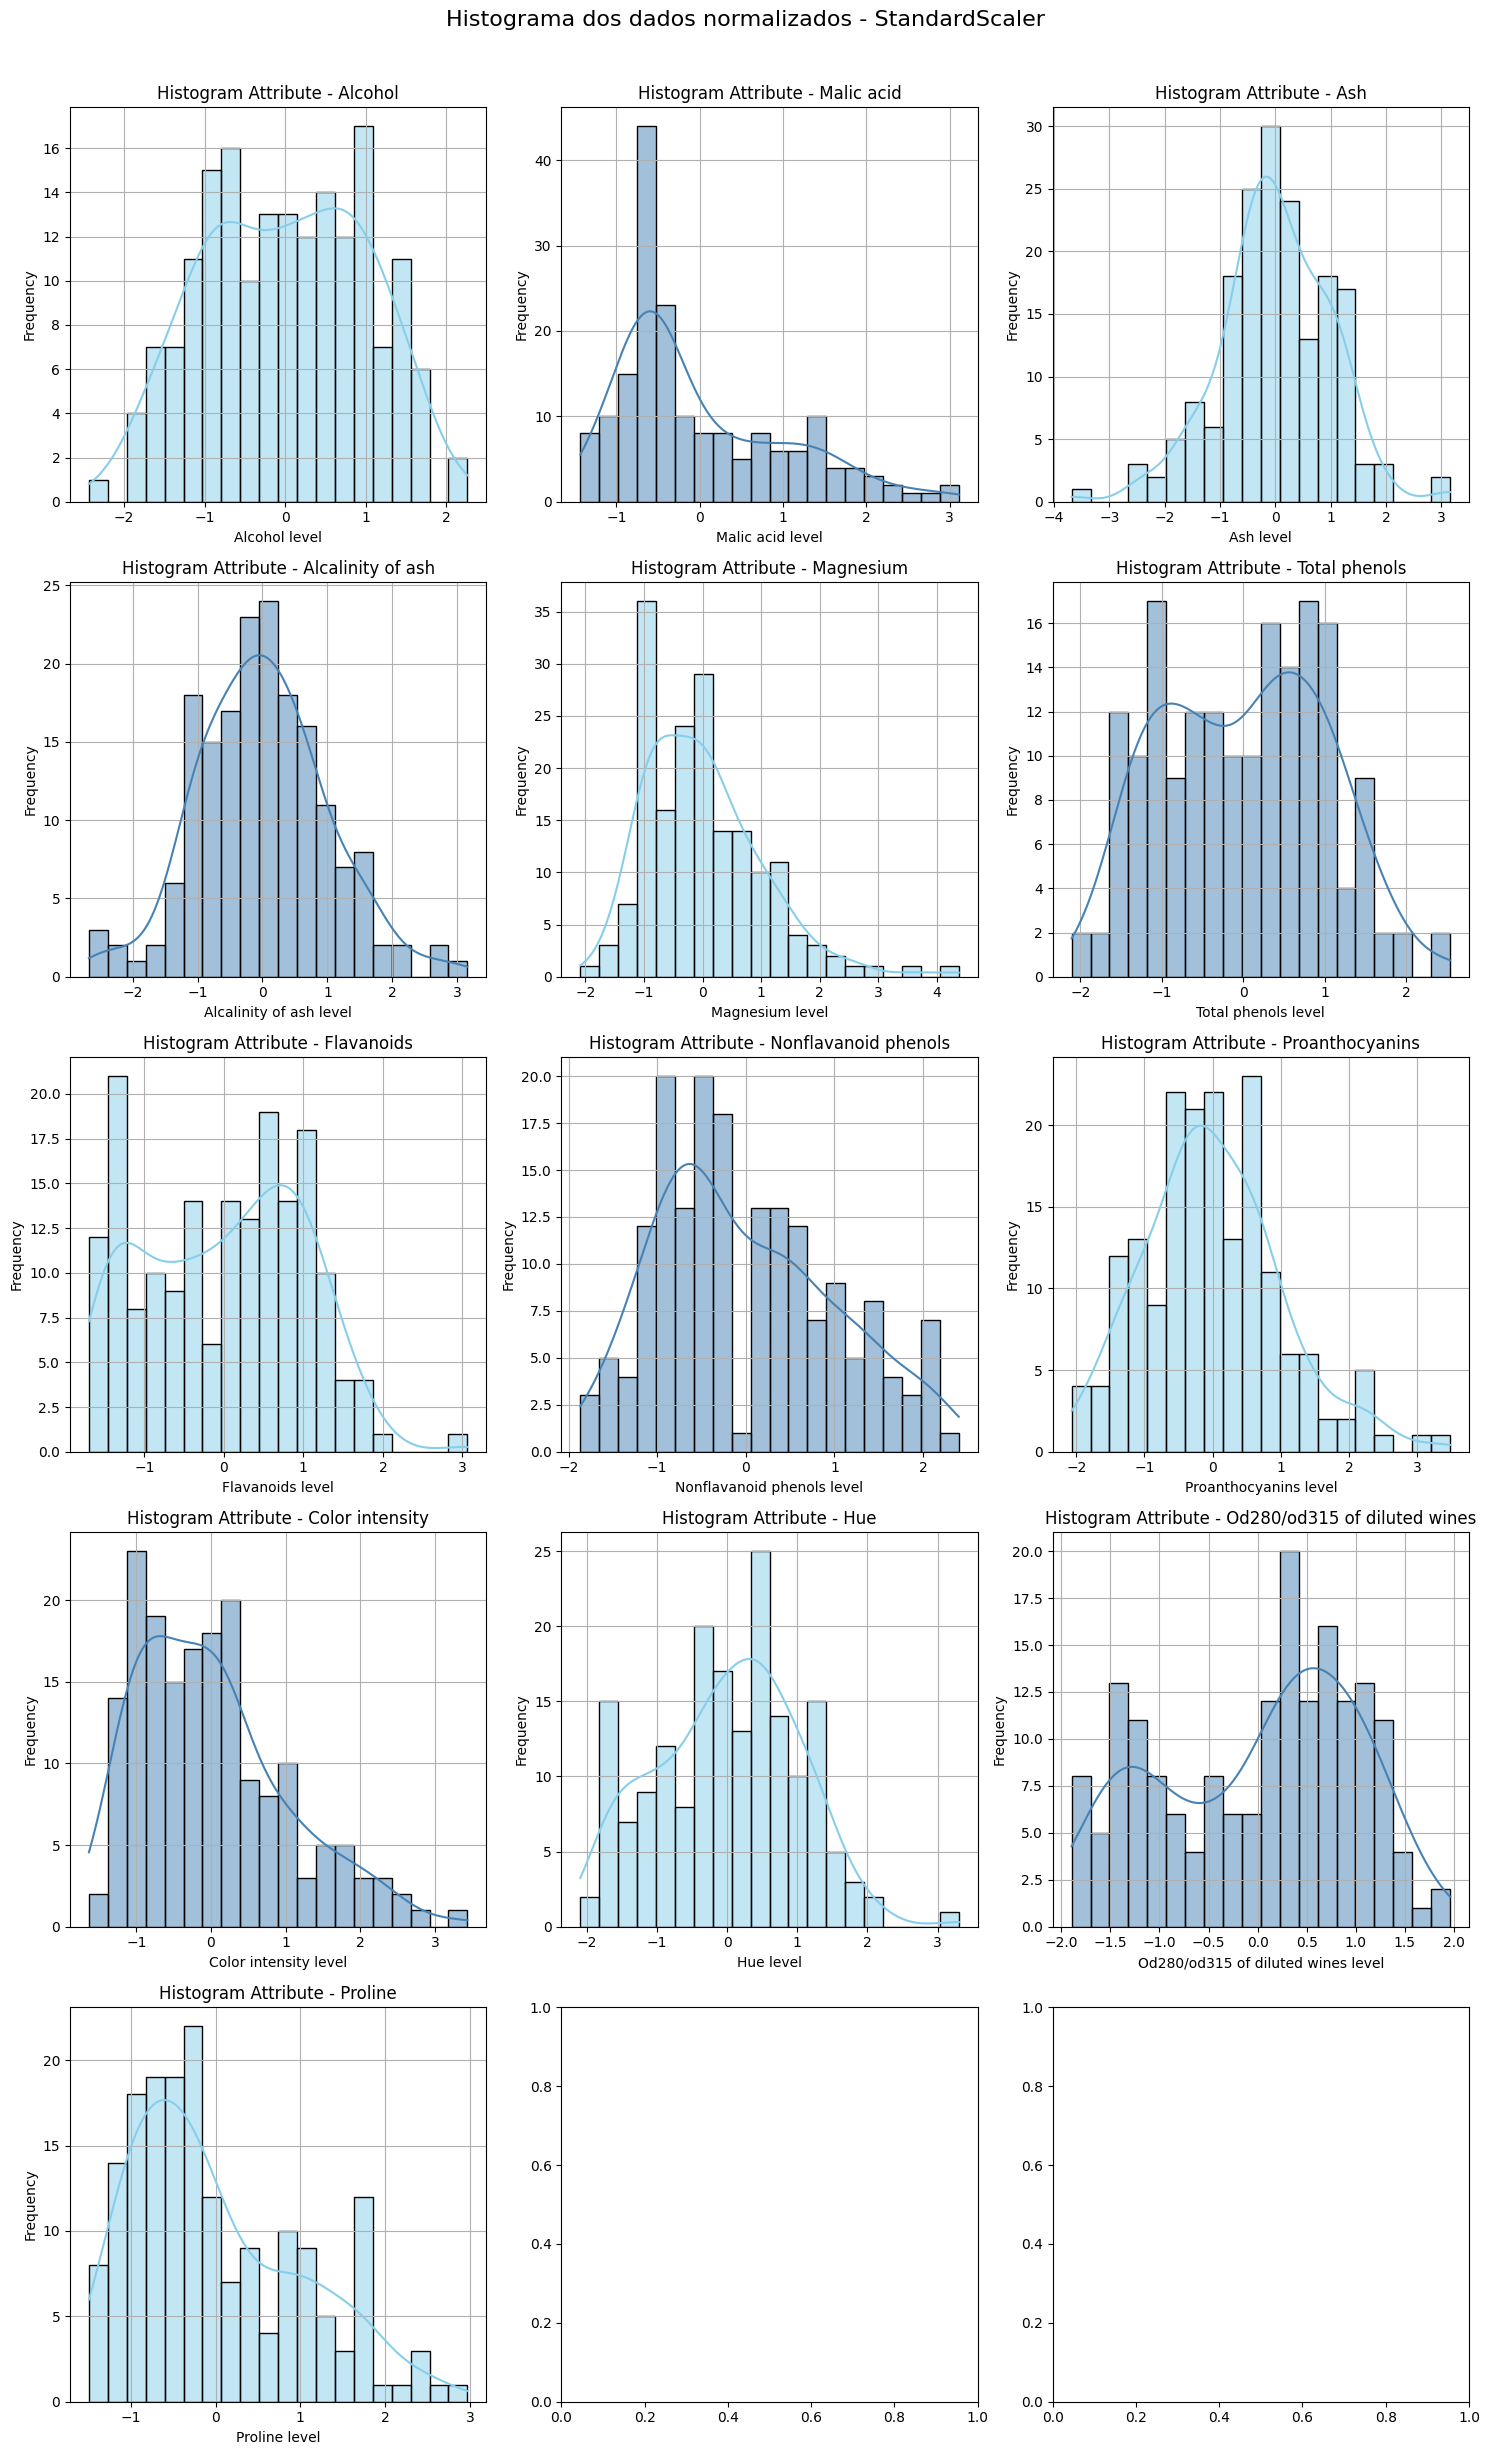

In [110]:
colors = ['skyblue', 'steelblue']
count = 0
fig, axes = plt.subplots(nrows=len(dfStandard.columns) // 3 + 1, ncols=3, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(dfStandard.select_dtypes(include=['float64']).columns):
    sns.histplot(dfStandard[col], kde=True, bins=20, color=colors[count % 2], ax=axes[i])
    colName = col.capitalize().replace('_', ' ')
    axes[i].set_title(f"Histogram Attribute - {colName}")
    axes[i].set_xlabel(f"{colName} level")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    count += 1

plt.suptitle("Histograma dos dados normalizados - StandardScaler", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


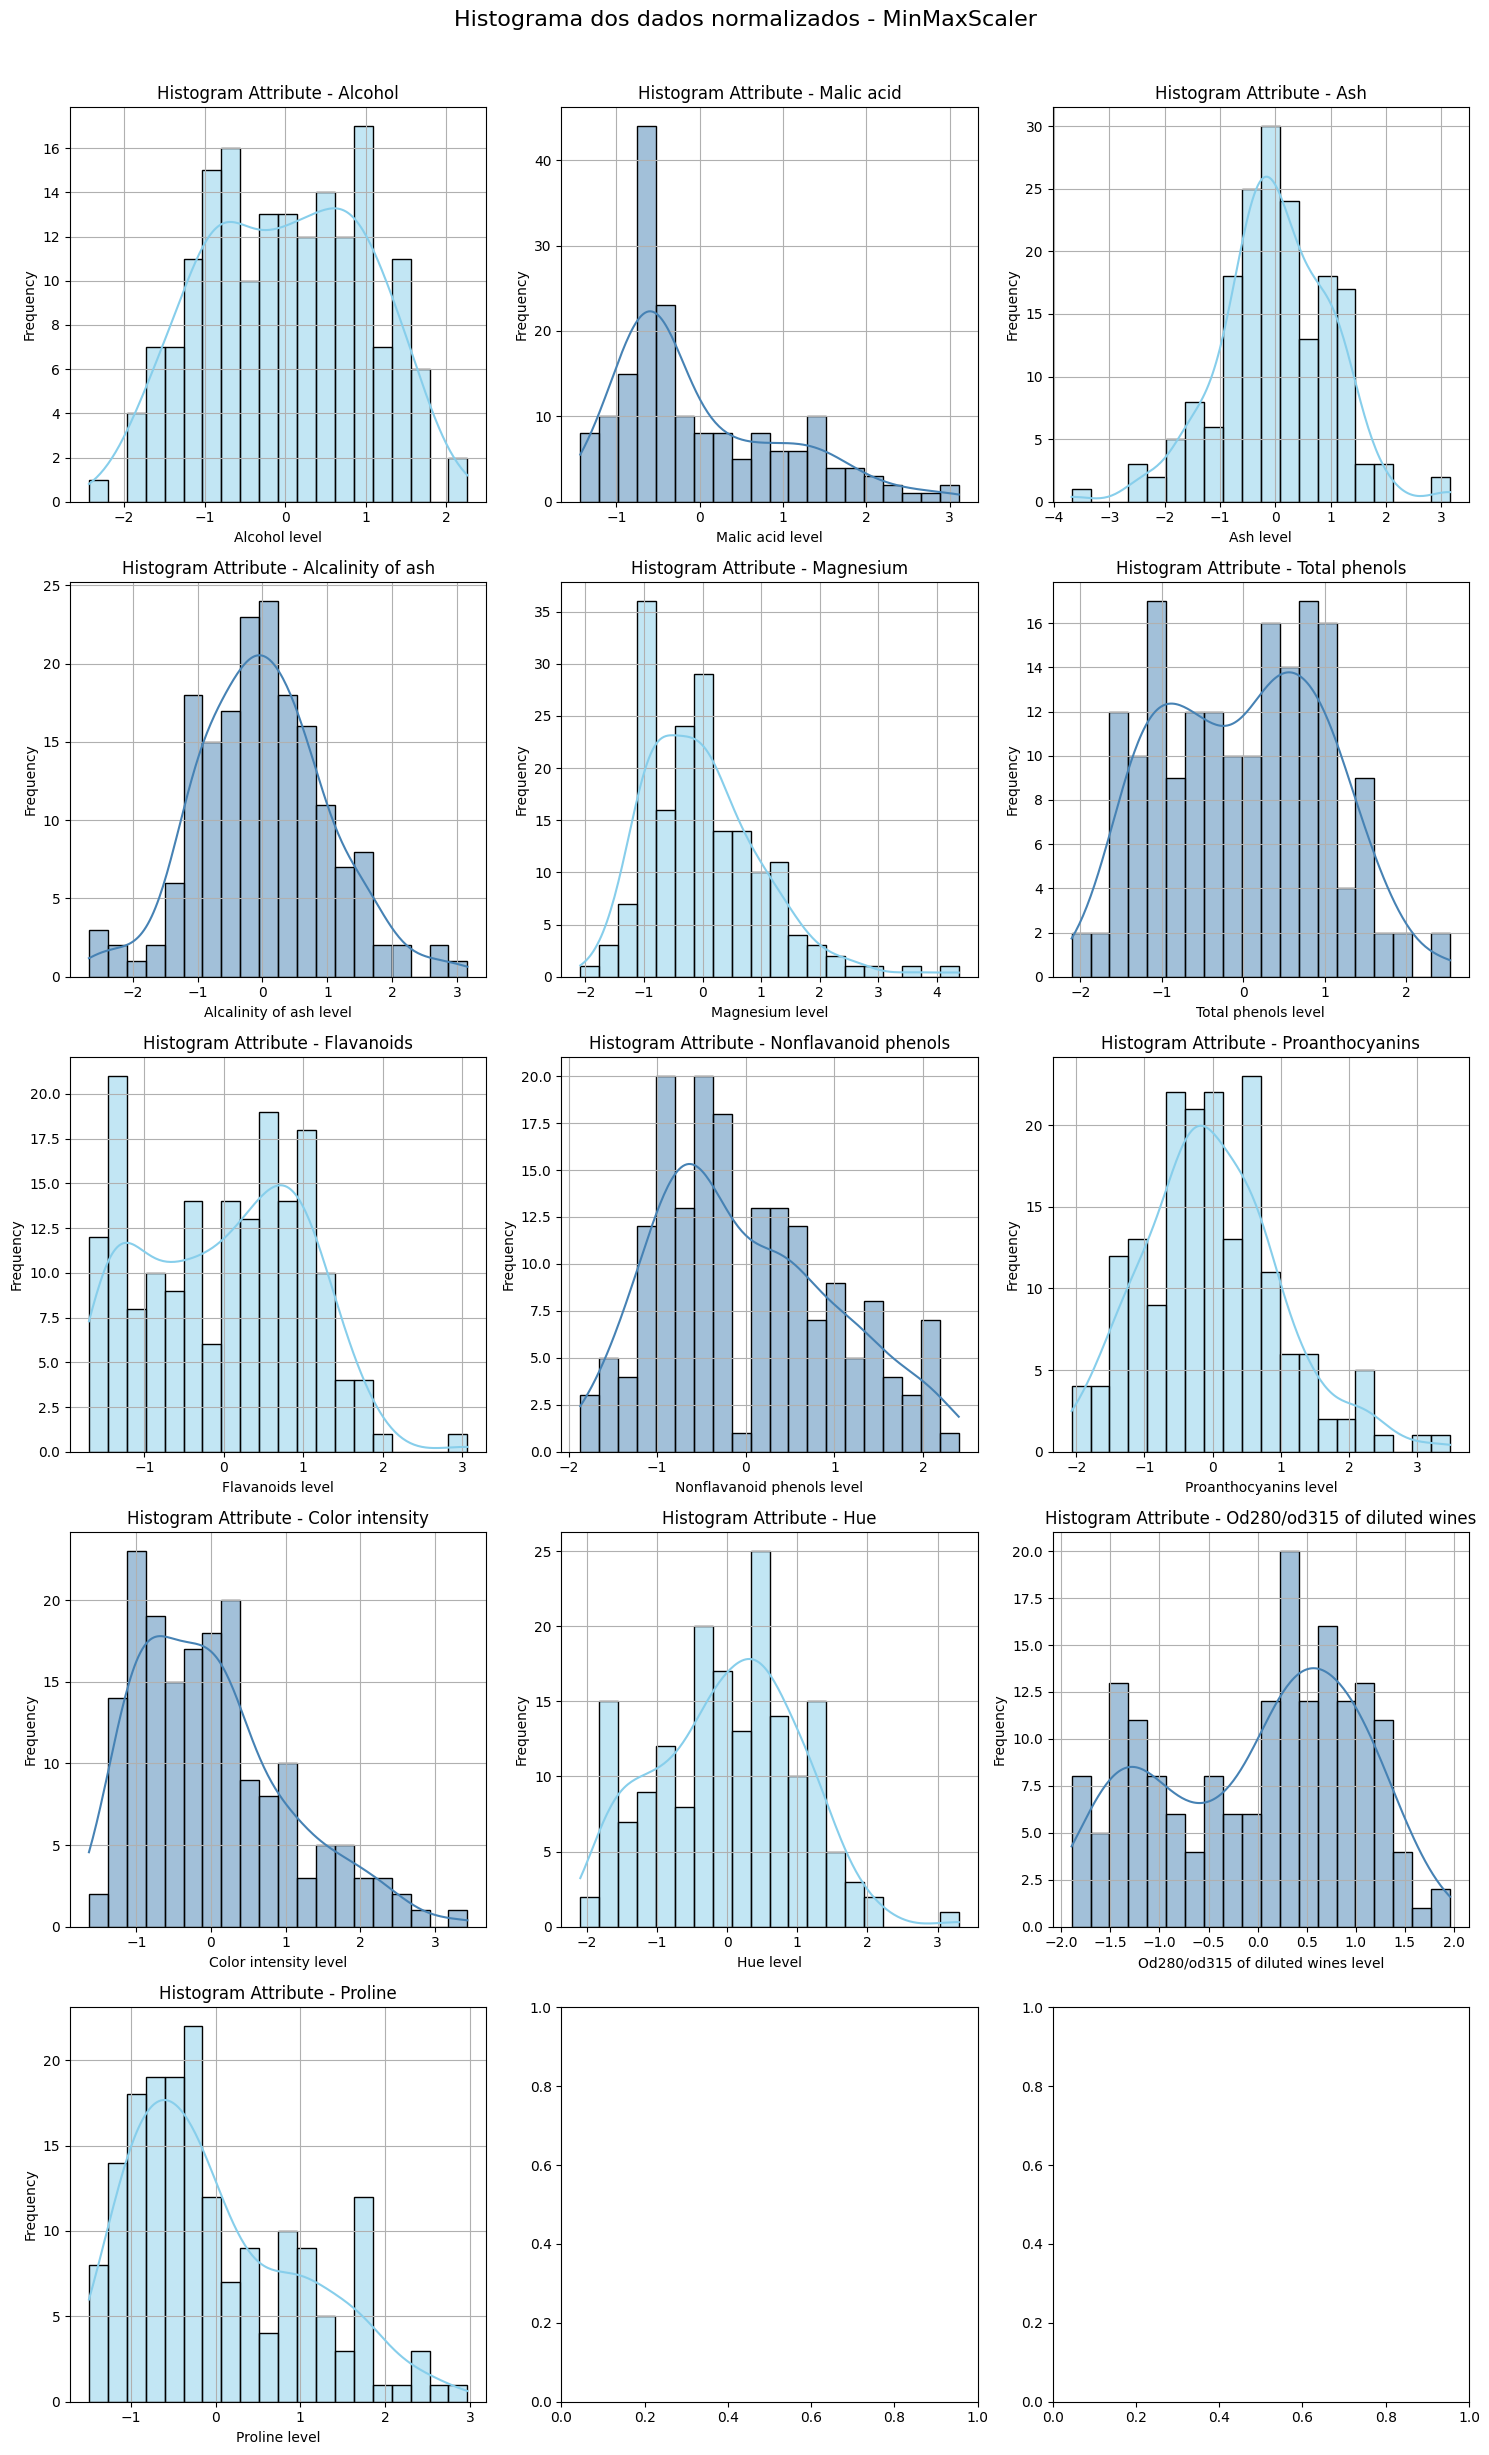

In [111]:
colors = ['skyblue', 'steelblue']
count = 0
fig, axes = plt.subplots(nrows=len(dfStandard.columns) // 3 + 1, ncols=3, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(dfStandard.select_dtypes(include=['float64']).columns):
    sns.histplot(dfStandard[col], kde=True, bins=20, color=colors[count % 2], ax=axes[i])
    colName = col.capitalize().replace('_', ' ')
    axes[i].set_title(f"Histogram Attribute - {colName}")
    axes[i].set_xlabel(f"{colName} level")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    count += 1

plt.suptitle("Histograma dos dados normalizados - MinMaxScaler", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
indexes_standard = np.random.choice(dfStandard.index, size=35, replace=False)
df_sample_standard = dfStandard.loc[indexes_standard].copy()

for i in ['ash', 'magnesium']:
    dfStandard.loc[indexes_standard,i] = np.nan

dfStandard.loc[indexes_standard, ['ash', 'magnesium']].head(15)

indexes_minmax = np.random.choice(dfMinMax.index, size=35, replace=False)
df_sample_minmax = dfMinMax.loc[indexes_minmax].copy()

for i in ['ash', 'magnesium']:
    dfMinMax.loc[indexes_minmax,i] = np.nan

dfMinMax.loc[indexes_minmax, ['ash', 'magnesium']].head(15)

indexes = np.random.choice(dfWine.index, size=35, replace=False)
df_sample = dfWine.loc[indexes].copy()

for i in ['ash', 'magnesium']:
    dfWine.loc[indexes,i] = np.nan

dfWine.loc[indexes, ['ash', 'magnesium']].head(15)


,ash,magnesium
96,NaN,NaN
64,NaN,NaN
88,NaN,NaN
167,NaN,NaN
49,NaN,NaN
132,NaN,NaN
86,NaN,NaN
18,NaN,NaN
12,NaN,NaN
22,NaN,NaN


### Imputação com Dados Normalizados

In [128]:
def avaliar_imputacao(imputer, df_com_nan, original, indices, colunas):
    df_copia = df_com_nan.copy()
    df_imputado = pd.DataFrame(imputer.fit_transform(df_copia), columns=df_com_nan.columns)

    imputados = df_imputado.loc[indices, colunas]
    verdadeiro = original.loc[indices, colunas]

    erro = {}
    for col in colunas:
        erro[col] = mean_absolute_error(verdadeiro[col], imputados[col])

    return erro

In [137]:
#SimpleImputer - Original
strategies = ['mean', 'median', 'most_frequent']
resultados_simple = {}

dfWine_nan = dfWine.copy()
for col in ['alcohol', 'malic_acid']:
    dfWine_nan.loc[indexes_standard, col] = np.nan
    
for strat in strategies:
    imputer = SimpleImputer(strategy=strat)
    erro = avaliar_imputacao(imputer, dfWine_nan, df_sample, indexes, ['alcohol', 'malic_acid'])
    resultados_simple[strat] = erro

In [ ]:
#SimpleImputer - Standard Scaler
resultados_simple_standard = {}

dfStandard_nan = dfStandard.copy()
for col in ['alcohol', 'malic_acid']:
    dfStandard_nan.loc[indexes_standard, col] = np.nan
    
for strat in strategies:
    imputer = SimpleImputer(strategy=strat)
    erro = avaliar_imputacao(imputer, dfStandard_nan, df_sample_standard, indexes_standard, ['alcohol', 'malic_acid'])
    resultados_simple_standard[strat] = erro

In [130]:
#SimpleImputer - Min Max Scaler
resultados_simple_min_max = {}

dfMinMax_nan = dfMinMax.copy()
for col in ['alcohol', 'malic_acid']:
    dfMinMax_nan.loc[indexes_minmax, col] = np.nan
    
for strat in strategies:
    imputer = SimpleImputer(strategy=strat)
    erro = avaliar_imputacao(imputer, dfMinMax_nan, df_sample_minmax, indexes_minmax, ['alcohol', 'malic_acid'])
    resultados_simple_min_max[strat] = erro

In [138]:
#IterativeImputer - Original
iteracoes = [5, 10]
resultados_iterative = {}

for it in iteracoes:
    imputer = IterativeImputer(max_iter=it, random_state=42)
    erro = avaliar_imputacao(imputer, dfWine_nan, df_sample, indexes, ['alcohol', 'malic_acid'])
    resultados_iterative[f'iter_{it}'] = erro

In [ ]:
#IterativeImputer - Standard Scaler
resultados_iterative_standard = {}

for it in iteracoes:
    imputer = IterativeImputer(max_iter=it, random_state=42)
    erro = avaliar_imputacao(imputer, dfStandard_nan, df_sample_standard, indexes_standard, ['alcohol', 'malic_acid'])
    resultados_iterative_standard[f'iter_{it}'] = erro

In [132]:
#IterativeImputer - Min Max Scaler

resultados_iterativemin_max = {}

for it in iteracoes:
    imputer = IterativeImputer(max_iter=it, random_state=42)
    erro = avaliar_imputacao(imputer, dfMinMax_nan, df_sample_minmax,indexes_minmax, ['alcohol', 'malic_acid'])
    resultados_iterativemin_max[f'iter_{it}'] = erro

In [140]:
#KNNImputer - Original
vizinhancas = [2, 5, 10]
resultados_knn = {}

for n in vizinhancas:
    imputer = KNNImputer(n_neighbors=n)
    erro = avaliar_imputacao(imputer, dfWine_nan, df_sample, indexes, ['alcohol', 'malic_acid'])
    resultados_knn[f'nn_{n}'] = erro

In [141]:
#KNNImputer - Standard Scaler
resultados_knn_standard = {}

for n in vizinhancas:
    imputer = KNNImputer(n_neighbors=n)
    erro = avaliar_imputacao(imputer, dfStandard_nan, df_sample_standard, indexes_standard, ['alcohol', 'malic_acid'])
    resultados_knn_standard[f'nn_{n}'] = erro

In [134]:
#KNNImputer - Min Max Scaler
resultados_knn_minmax = {}

for n in vizinhancas:
    imputer = KNNImputer(n_neighbors=n)
    erro = avaliar_imputacao(imputer, dfMinMax_nan, df_sample_minmax, indexes_minmax, ['alcohol', 'malic_acid'])
    resultados_knn_minmax[f'nn_{n}'] = erro

In [142]:
print("Resultados Originais: \n")

print("Erros - SimpleImputer:")
print(resultados_simple)

print("\nErros - IterativeImputer:")
print(resultados_iterative)

print("\nErros - KNNImputer:")
print(resultados_knn)

Resultados Originais: 

Erros - SimpleImputer:
{'mean': {'alcohol': 0.17046553446553447, 'malic_acid': 0.17477722277722277}, 'median': {'alcohol': 0.168, 'malic_acid': 0.22057142857142853}, 'most_frequent': {'alcohol': 0.24457142857142858, 'malic_acid': 0.23199999999999998}}

Erros - IterativeImputer:
{'iter_5': {'alcohol': 0.10944504676104226, 'malic_acid': 0.13937656739160503}, 'iter_10': {'alcohol': 0.10944504676104226, 'malic_acid': 0.13937656739160503}}

Erros - KNNImputer:
{'nn_2': {'alcohol': 0.17357142857142854, 'malic_acid': 0.16114285714285717}, 'nn_5': {'alcohol': 0.12554285714285704, 'malic_acid': 0.15565714285714283}, 'nn_10': {'alcohol': 0.12785714285714284, 'malic_acid': 0.14394285714285715}}


In [143]:
print("Resultados StandardScaler: \n")

print("Erros - SimpleImputer:")
print(resultados_simple_standard)

print("\nErros - IterativeImputer:")
print(resultados_iterative_standard)

print("\nErros - KNNImputer:")
print(resultados_knn_standard)

Resultados StandardScaler: 

Erros - SimpleImputer:
{'mean': {'alcohol': 0.814196333879042, 'malic_acid': 0.9348879179972599}, 'median': {'alcohol': 0.8096279513610434, 'malic_acid': 0.9517794095161867}, 'most_frequent': {'alcohol': 1.2934988848030617, 'malic_acid': 0.969219722059194}}

Erros - IterativeImputer:
{'iter_5': {'alcohol': 0.6039890308360975, 'malic_acid': 0.6966223684581753}, 'iter_10': {'alcohol': 0.6039890308360975, 'malic_acid': 0.6966223684581753}}

Erros - KNNImputer:
{'nn_2': {'alcohol': 0.5923977839405019, 'malic_acid': 0.8320054983752382}, 'nn_5': {'alcohol': 0.6125502495127405, 'malic_acid': 0.7645525248633126}, 'nn_10': {'alcohol': 0.5497282027201227, 'malic_acid': 0.7236703804610273}}


In [144]:
print("Resultados MinMaxScaler: \n")

print("Erros - SimpleImputer:")
print(resultados_simple_min_max)

print("\nErros - IterativeImputer:")
print(resultados_iterativemin_max)

print("\nErros - KNNImputer:")
print(resultados_knn_minmax)

Resultados MinMaxScaler: 

Erros - SimpleImputer:
{'mean': {'alcohol': 0.19305273673694723, 'malic_acid': 0.18031415225091116}, 'median': {'alcohol': 0.19075187969924806, 'malic_acid': 0.17052512704686618}, 'most_frequent': {'alcohol': 0.25285714285714295, 'malic_acid': 0.1751552795031056}}

Erros - IterativeImputer:
{'iter_5': {'alcohol': 0.12895636744256858, 'malic_acid': 0.12342409735732494}, 'iter_10': {'alcohol': 0.12895636744256858, 'malic_acid': 0.12342409735732494}}

Erros - KNNImputer:
{'nn_2': {'alcohol': 0.14011278195488722, 'malic_acid': 0.1557029926595144}, 'nn_5': {'alcohol': 0.10775939849624054, 'malic_acid': 0.13351778656126484}, 'nn_10': {'alcohol': 0.09209022556390972, 'malic_acid': 0.13224167137210616}}


### MAE Dados Originais

In [145]:
# Combinar todos os resultados em um único dicionário para cada coluna
mae_alcohol = {
    'Simple - mean': resultados_simple['mean']['alcohol'],
    'Simple - median': resultados_simple['median']['alcohol'],
    'Simple - most_frequent': resultados_simple['most_frequent']['alcohol'],
    'Iterative - 5': resultados_iterative['iter_5']['alcohol'],
    'Iterative - 10': resultados_iterative['iter_10']['alcohol'],
    'KNN - 2': resultados_knn['nn_2']['alcohol'],
    'KNN - 5': resultados_knn['nn_5']['alcohol'],
    'KNN - 10': resultados_knn['nn_10']['alcohol'],
}

mae_malic_acid = {
    'Simple - mean': resultados_simple['mean']['malic_acid'],
    'Simple - median': resultados_simple['median']['malic_acid'],
    'Simple - most_frequent': resultados_simple['most_frequent']['malic_acid'],
    'Iterative - 5': resultados_iterative['iter_5']['malic_acid'],
    'Iterative - 10': resultados_iterative['iter_10']['malic_acid'],
    'KNN - 2': resultados_knn['nn_2']['malic_acid'],
    'KNN - 5': resultados_knn['nn_5']['malic_acid'],
    'KNN - 10': resultados_knn['nn_10']['malic_acid'],
}

# 6. Construa dois dicionários ou dataframes (um para cada variável escolhidas no item 4) com o resultado de cada MAE para cada estratégia.
df_mae_alcohol = pd.DataFrame.from_dict(mae_alcohol, orient='index', columns=['MAE_alcohol'])
df_mae_malic = pd.DataFrame.from_dict(mae_malic_acid, orient='index', columns=['MAE_malic_acid'])

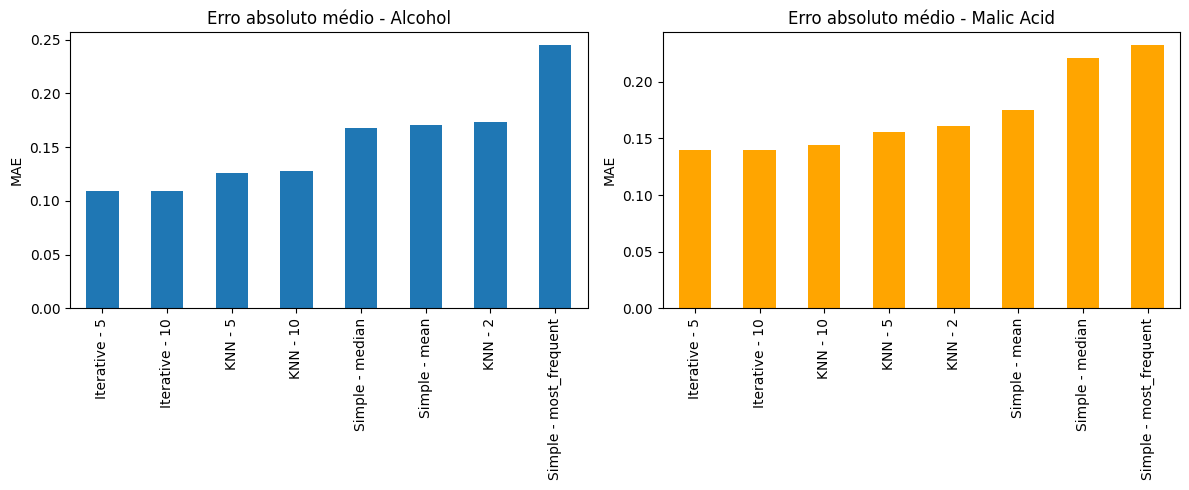

In [146]:
plt.figure(figsize=(12, 5))

# Alcohol
plt.subplot(1, 2, 1)
df_mae_alcohol.sort_values(by='MAE_alcohol').plot(kind='bar', legend=False, ax=plt.gca())
plt.title('Erro absoluto médio - Alcohol')
plt.ylabel('MAE')

# Malic Acid
plt.subplot(1, 2, 2)
df_mae_malic.sort_values(by='MAE_malic_acid').plot(kind='bar', legend=False, ax=plt.gca(), color='orange')
plt.title('Erro absoluto médio - Malic Acid')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

### MAE Standard Scaler

In [147]:
# Combinar todos os resultados em um único dicionário para cada coluna
mae_alcohol = {
    'Simple - mean': resultados_simple['mean']['alcohol'],
    'Simple - median': resultados_simple['median']['alcohol'],
    'Simple - most_frequent': resultados_simple['most_frequent']['alcohol'],
    'Iterative - 5': resultados_iterative['iter_5']['alcohol'],
    'Iterative - 10': resultados_iterative['iter_10']['alcohol'],
    'KNN - 2': resultados_knn['nn_2']['alcohol'],
    'KNN - 5': resultados_knn['nn_5']['alcohol'],
    'KNN - 10': resultados_knn['nn_10']['alcohol'],
}

mae_malic_acid = {
    'Simple - mean': resultados_simple['mean']['malic_acid'],
    'Simple - median': resultados_simple['median']['malic_acid'],
    'Simple - most_frequent': resultados_simple['most_frequent']['malic_acid'],
    'Iterative - 5': resultados_iterative['iter_5']['malic_acid'],
    'Iterative - 10': resultados_iterative['iter_10']['malic_acid'],
    'KNN - 2': resultados_knn['nn_2']['malic_acid'],
    'KNN - 5': resultados_knn['nn_5']['malic_acid'],
    'KNN - 10': resultados_knn['nn_10']['malic_acid'],
}

# 6. Construa dois dicionários ou dataframes (um para cada variável escolhidas no item 4) com o resultado de cada MAE para cada estratégia.
df_mae_alcohol = pd.DataFrame.from_dict(mae_alcohol, orient='index', columns=['MAE_alcohol'])
df_mae_malic = pd.DataFrame.from_dict(mae_malic_acid, orient='index', columns=['MAE_malic_acid'])


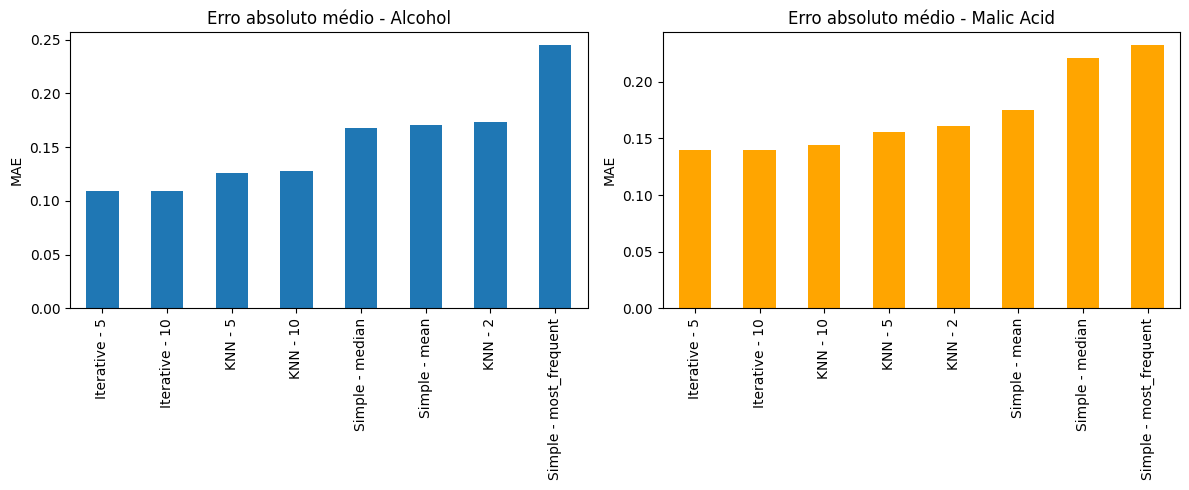

In [148]:
plt.figure(figsize=(12, 5))

# Alcohol
plt.subplot(1, 2, 1)
df_mae_alcohol.sort_values(by='MAE_alcohol').plot(kind='bar', legend=False, ax=plt.gca())
plt.title('Erro absoluto médio - Alcohol')
plt.ylabel('MAE')

# Malic Acid
plt.subplot(1, 2, 2)
df_mae_malic.sort_values(by='MAE_malic_acid').plot(kind='bar', legend=False, ax=plt.gca(), color='orange')
plt.title('Erro absoluto médio - Malic Acid')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

### MAE MinMaxScaler

In [149]:
# Combinar todos os resultados em um único dicionário para cada coluna
mae_alcohol_minmax = {
    'Simple - mean': resultados_simple_min_max['mean']['alcohol'],
    'Simple - median': resultados_simple_min_max['median']['alcohol'],
    'Simple - most_frequent': resultados_simple_min_max['most_frequent']['alcohol'],
    'Iterative - 5': resultados_iterativemin_max['iter_5']['alcohol'],
    'Iterative - 10': resultados_iterativemin_max['iter_10']['alcohol'],
    'KNN - 2': resultados_knn_minmax['nn_2']['alcohol'],
    'KNN - 5': resultados_knn_minmax['nn_5']['alcohol'],
    'KNN - 10': resultados_knn_minmax['nn_10']['alcohol'],
}

mae_malic_acid_minmax = {
    'Simple - mean': resultados_simple_min_max['mean']['malic_acid'],
    'Simple - median': resultados_simple_min_max['median']['malic_acid'],
    'Simple - most_frequent': resultados_simple_min_max['most_frequent']['malic_acid'],
    'Iterative - 5': resultados_iterativemin_max['iter_5']['malic_acid'],
    'Iterative - 10': resultados_iterativemin_max['iter_10']['malic_acid'],
    'KNN - 2': resultados_knn_minmax['nn_2']['malic_acid'],
    'KNN - 5': resultados_knn_minmax['nn_5']['malic_acid'],
    'KNN - 10': resultados_knn_minmax['nn_10']['malic_acid'],
}

df_mae_alcohol = pd.DataFrame.from_dict(mae_alcohol_minmax, orient='index', columns=['MAE_alcohol'])
df_mae_malic = pd.DataFrame.from_dict(mae_malic_acid_minmax, orient='index', columns=['MAE_malic_acid'])

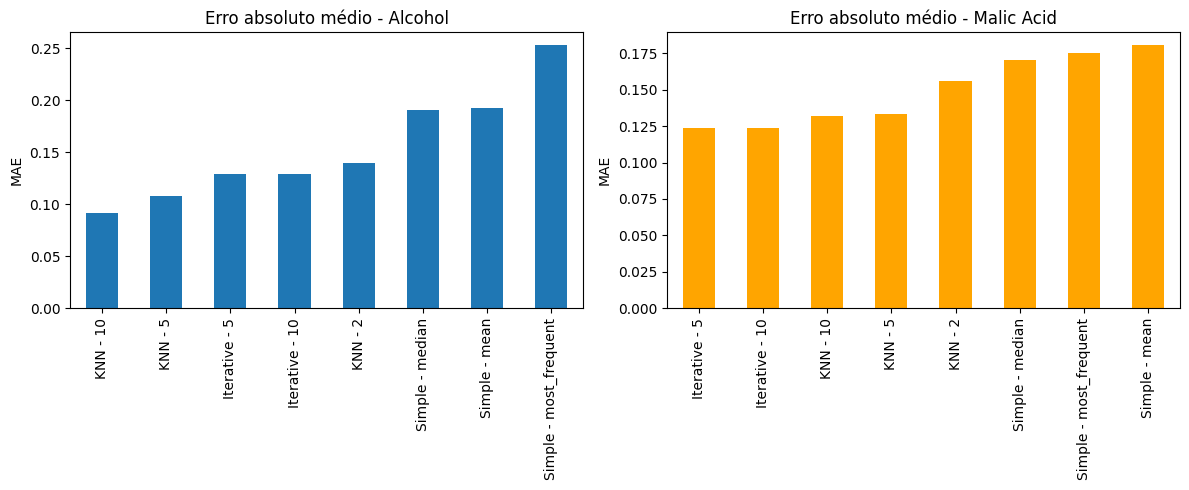

In [150]:
plt.figure(figsize=(12, 5))

# Alcohol
plt.subplot(1, 2, 1)
df_mae_alcohol.sort_values(by='MAE_alcohol').plot(kind='bar', legend=False, ax=plt.gca())
plt.title('Erro absoluto médio - Alcohol')
plt.ylabel('MAE')

# Malic Acid
plt.subplot(1, 2, 2)
df_mae_malic.sort_values(by='MAE_malic_acid').plot(kind='bar', legend=False, ax=plt.gca(), color='orange')
plt.title('Erro absoluto médio - Malic Acid')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()